In [ ]:
"""
create a READ token and copy paste if you're not already logged in to huggingface
you can uncheck 'Add token as git credential?'
"""

from huggingface_hub import notebook_login
notebook_login()

In [ ]:
"""
(re)generate a puzzle layout with exactly 2 solutions
Will install required julia packages on first use
"""

import subprocess
import helpers

def generate_puzzle(w, h, num_iterations=1000000):
    dir_path = helpers.get_src_path()
    command = (
        f'using Pkg; '
        f'Pkg.activate(".."); '
        f'Pkg.instantiate(); '
        f'include("generate_puzzle.jl"); '
        f'generate_puzzle({w}, {h}, {num_iterations})'
    )
    out = subprocess.run(["julia", "-e", command], cwd=dir_path)
    print(out)
    

generate_puzzle(6, 6, 1000000)


  0%|          | 0/35 [00:00<?, ?it/s]

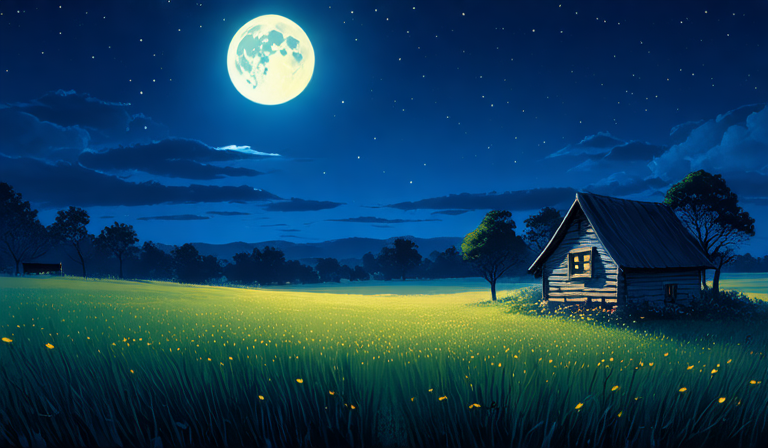

In [11]:
"""
just generate an image
"""

import image


prompt = "illustration of the countryside by night during full moon, in a field next to a small house, anime style"

out = image.generate(
    prompt=prompt,
    width=768,
    height=448,
    num_inference_steps=35,
    negative_prompt="",
    guidance_scale=7
)

# save with 
# out.save("../out/image.png")

out


In [ ]:
"""
generate a puzzle image, using a given image for one of the two puzzle solutions
"""

import os
import helpers
import similar_puzzle_image
dir_path = helpers.get_src_path()



prompt = "nice sports car in the streets of tokyo, anime style"

target_image = os.path.join(dir_path, "../assets/pearl.jpg")

out = similar_puzzle_image.generate(
    puzzle_w=6,
    puzzle_h=6,
    prompt=prompt,
    target_img_path=target_image,
    num_inference_steps=50,
    hint_weight=0.6, # initial weight for the target image
    hint_until=0.9, # percentage, how long to use the target image for steering
    negative_prompt="realism, photography",
    guidance_scale=7
)

# save with 
# out[0].save("../out/similar_puzzle1.png")
# out[1].save("../out/similar_puzzle2.png")

display(out[0])
display(out[1])

In [ ]:
"""
generate puzzle images, given two prompts
"""

import puzzle_image

prompt1 = "illustration of the countryside by night during full moon, in a field next to a small house, anime style"
prompt2 = "nice sports car in the streets of tokyo, anime style, studio ghibli"


out = puzzle_image.generate(
    puzzle_w=12,
    puzzle_h=7,
    prompt1=prompt1,
    prompt2=prompt2,
    num_inference_steps=60,
    negative_prompt1="",
    negative_prompt2="",
    guidance_scale=7,
    refine_seperately=True,
    refine_seperately_amount=0.2,
    seed=42
)

# save with 
# out[0].save("../out/puzzle1.png")
# out[1].save("../out/puzzle2.png")
for img in out:
    display(img)


  0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
out[0].save("../out/carhouse80_0.png")
out[1].save("../out/carhouse80_1.png")

In [ ]:
"""
generate a bunch puzzle images, given two prompts
for when you want to generate a whole bunch to choose the best one at the end
"""

import puzzle_image

prompt1 = "detailed painting of a colorful bird on a twig, on a white background. The bird appears to be made up of flowers and flower petals"
prompt2 = "detailed painting of a pretty arrangement of colorful flowers and twigs with leaves, on a white background"

prompt1 = "painting of a kitchen"
prompt2 = "painting of a deer"

j = 0
for i in range(10):

    out = puzzle_image.generate(
        puzzle_w=4,
        puzzle_h=4,
        prompt1=prompt1,
        prompt2=prompt2,
        num_inference_steps=35,
        negative_prompt1="realism",
        negative_prompt2="",
        refine_seperately=True,
        guidance_scale=7,
    )

    out[0].save(f"../out/puzzle{j}.png")
    j += 1
    out[1].save(f"../out/puzzle{j}.png")
    j += 1

    display(out[0])
    display(out[1])